In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("dataset.csv")

In [6]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [16]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [11]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [13]:
df.shape

(1000, 11)

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [17]:
df.describe(include= "all")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [21]:
df["Job"].unique()

array([2, 1, 3, 0])

In [22]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [29]:
df = df.dropna().reset_index(drop=True)

In [30]:
df


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [31]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [34]:
df.drop(columns= "Unnamed: 0" , inplace = True)

In [35]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Credit amount'}>],
       [<Axes: title={'center': 'Duration'}>, <Axes: >]], dtype=object)

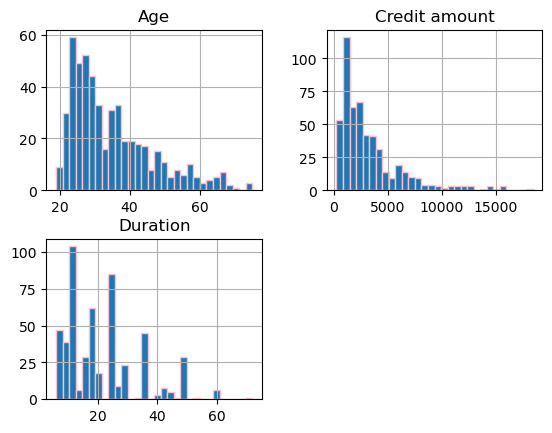

In [42]:
df[["Age","Credit amount","Duration"]].hist(bins=30 , edgecolor = "pink")


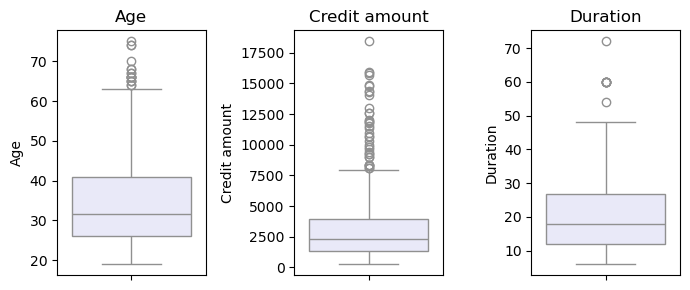

In [49]:
plt.figure(figsize=(7,3))
for i , col in enumerate(["Age" , "Credit amount" , "Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y = df[col], color = 'lavender')
    plt.title(col)

    plt.tight_layout()
    plt.show

In [63]:
a=df.query("Duration>=30")
a["Risk"].value_counts()

Risk
bad     78
good    44
Name: count, dtype: int64

In [60]:
b=df.query("Duration>=40")
b["Risk"].value_counts()

Risk
bad     39
good    13
Name: count, dtype: int64

In [67]:
c=df.query("Duration>=49")
c["Risk"].value_counts()

Risk
bad    8
Name: count, dtype: int64

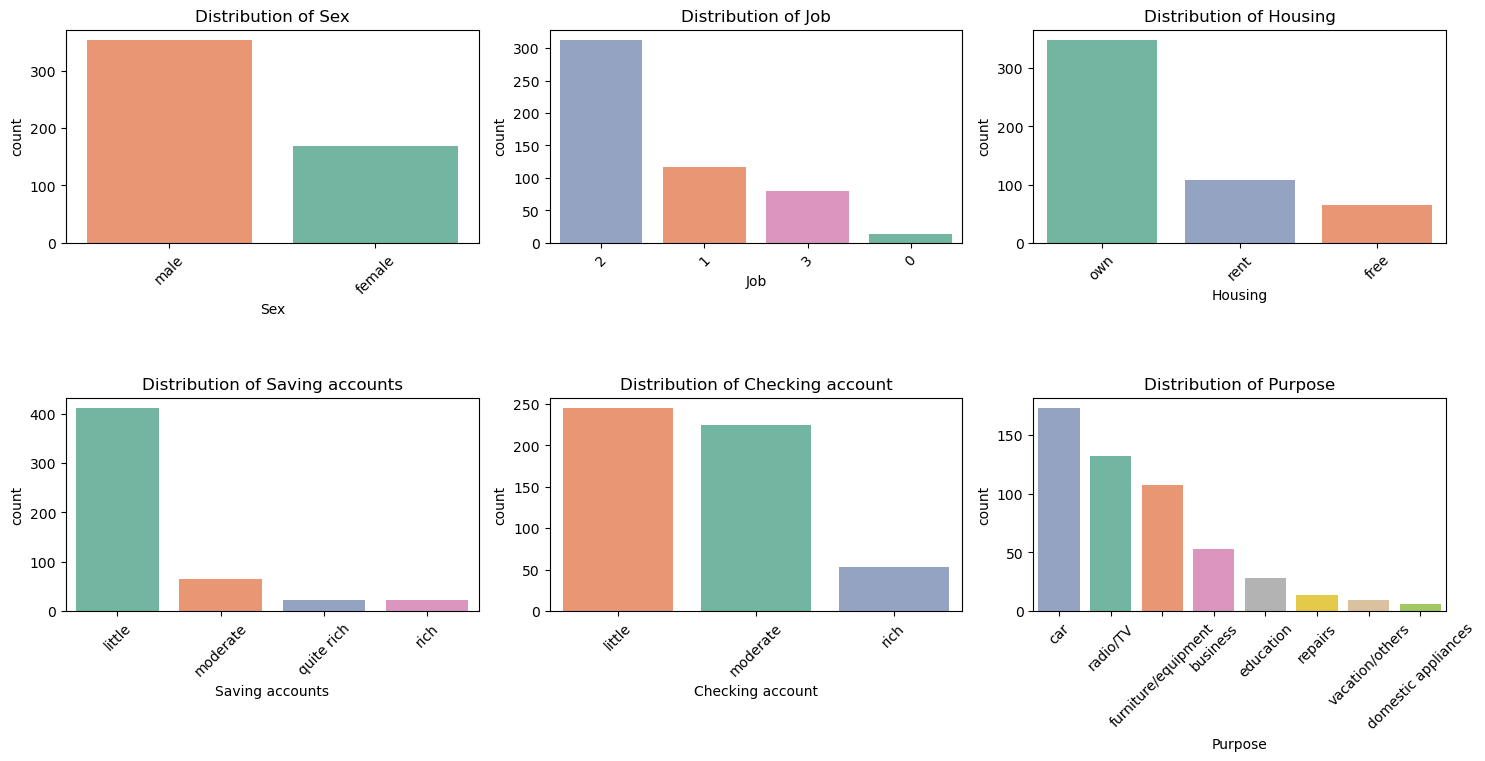

In [72]:
categories = ["Sex","Job","Housing","Saving accounts",
                    "Checking account","Purpose"]
plt.figure(figsize=(15,10))

for i, col in enumerate(categories):
    plt.subplot(3,3,i+1)

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        hue=col,
        palette='Set2',
        legend=False
    )

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [79]:
cm = df[["Age","Job","Credit amount","Duration"]].corr()
cm

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


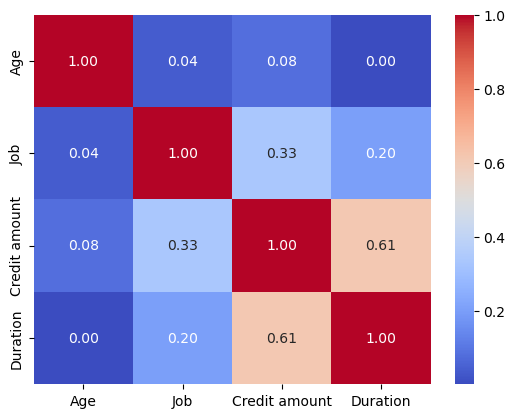

In [82]:
sns.heatmap(cm, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [81]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [83]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [84]:
pd.pivot_table(
    df,
    values="Credit amount",
    index="Housing",
    columns="Purpose"
)

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


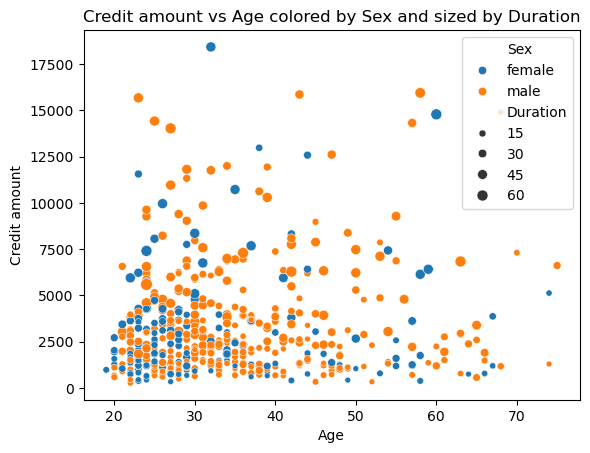

In [95]:
sns.scatterplot(
    data=df,
    x="Age",
    y="Credit amount",
    hue="Sex",
    size="Duration",
    palette="tab10"
)
plt.title("Credit amount vs Age colored by Sex and sized by Duration")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_12000\1431644572.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


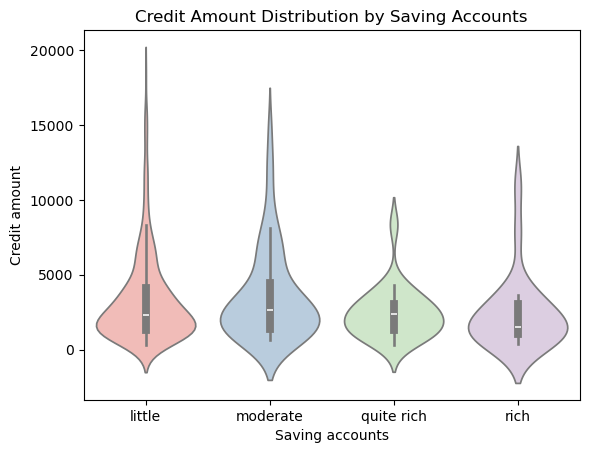

In [96]:
sns.violinplot(
    data=df,
    x="Saving accounts",
    y="Credit amount",
    palette="Pastel1"
)

plt.title("Credit Amount Distribution by Saving Accounts")
plt.show()

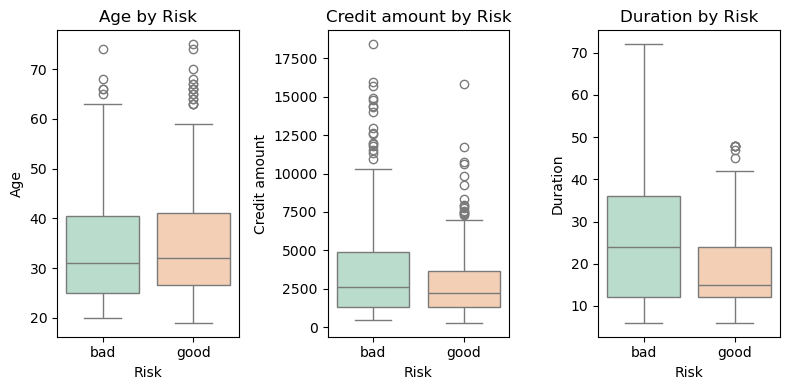

In [106]:
plt.figure(figsize=(8,4))

for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)

    sns.boxplot(
        data=df,
        x="Risk",
        y=col,
        hue="Risk",
        palette="Pastel2",
        legend=False
    )

    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

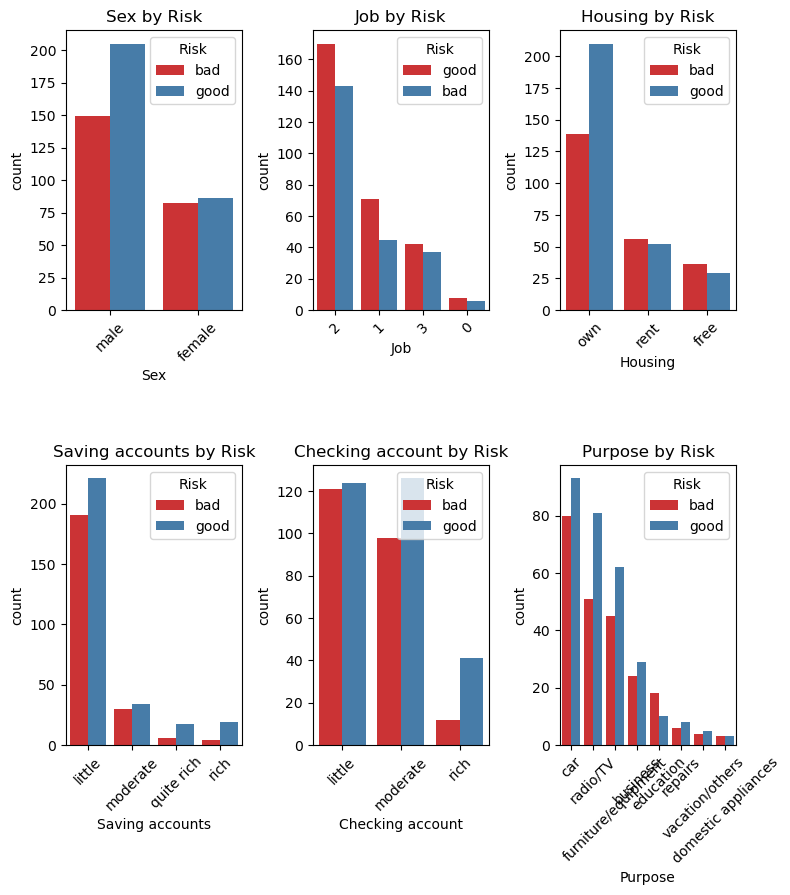

In [112]:
plt.figure(figsize=(8, 12))

for i, col in enumerate(categories):
    plt.subplot(3, 3, i + 1)

    sns.countplot(
        data=df,
        x=col,
        hue="Risk",
        palette="Set1",
        order=df[col].value_counts().index
    )

    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [114]:
features = [
    "Age", "Sex", "Job", "Housing",
    "Saving accounts", "Checking account",
    "Credit amount", "Duration", "Purpose"
]

target = "Risk"

df_model = df[features + [target]].copy()

In [115]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad


In [116]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [117]:
cat_cols = df_model.select_dtypes(include = "object").columns.drop("Risk") 

In [119]:
le_dict={}

In [120]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [121]:
for col in cat_cols:
    le = LabelEncoder()

    df_model[col] = le.fit_transform(df_model[col])

    le_dict[col] = le

    joblib.dump(le, f"{col}_encoder.pkl")

In [123]:
le_target = LabelEncoder()

In [124]:
target

'Risk'

In [125]:
df_model[target] = le_target.fit_transform(df_model[target])

In [127]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [129]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [130]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,0,2,1,0,1,5951,48,5,0
1,45,1,2,0,0,0,7882,42,4,1
2,53,1,2,0,0,0,4870,24,1,0
3,35,1,3,2,0,1,6948,36,1,1
4,28,1,3,1,0,1,5234,30,1,0


In [131]:
from sklearn.model_selection import train_test_split

In [132]:
X = df_model.drop(target, axis =1 )

In [150]:
y = df_model[target]

In [153]:

x=X
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,22,0,2,1,0,1,5951,48,5
1,45,1,2,0,0,0,7882,42,4
2,53,1,2,0,0,0,4870,24,1
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,1
...,...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24,5
518,30,1,3,1,0,0,3959,36,4
519,40,1,3,1,0,0,3857,30,1
520,23,1,2,0,0,0,1845,45,5


In [154]:
y=Y
Y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=1
)

In [155]:
X_train.shape

(417, 9)

In [156]:
X_test.shape

(105, 9)

In [157]:
!pip install xgboost
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

from sklearn.model_selection import GridSearchCV

In [158]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [160]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=1,
    class_weight="balanced"
)

dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


In [161]:
best_dt, acc_dt, params_dt = train_model(
    dt,
    dt_param_grid,
    X_train,
    y_train,
    X_test,
    y_test
)

In [162]:
print("Decision Tree Accuracy",acc_dt)

Decision Tree Accuracy 0.5904761904761905


In [163]:
print("Best Parameters", params_dt)

Best Parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [166]:
rf = RandomForestClassifier(
    random_state=1,
    class_weight="balanced",
    n_jobs = -1
)

In [167]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [168]:
best_rf, acc_rf, params_rf = train_model(
    rf,
    rf_param_grid,
    X_train,
    y_train,
    X_test,
    y_test
)

In [169]:
print("Random Forest Accuracy",acc_rf)

Random Forest Accuracy 0.638095238095238


In [170]:
print("Best parameter", params_rf)

Best parameter {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [171]:
et = ExtraTreesClassifier(
    random_state=1,
    class_weight="balanced",
    n_jobs=-1
)

In [172]:
et_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [173]:
best_et, acc_et, params_et = train_model(
    et,
    et_param_grid,
    X_train,
    y_train,
    X_test,
    y_test
)

In [174]:
print("extra trees accuracy", acc_et)

extra trees accuracy 0.638095238095238


In [177]:
print("best parameters", params_et)

best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [179]:
xgb = XGBClassifier(
    random_state=1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    use_label_encoder=False,
    eval_metric="logloss"
)

In [180]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1],
    "colsample_bytree": [0.7, 1]
}

In [182]:
best_xgb, acc_xgb, params_xgb = train_model(
    xgb,
    xgb_param_grid,
    X_train,
    y_train,
    X_test,
    y_test
)

C:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:02:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [183]:
print("Accuracy:", acc_xgb)
print("Best Parameters:", params_xgb)

Accuracy: 0.6666666666666666
Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [185]:
best_xgb.predict(X_test)

array([1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0])

In [186]:
joblib.dump(best_xgb, "XGboost_credit_model.pkl")

['XGboost_credit_model.pkl']

In [187]:
df["Purpose"].unique()

array(['radio/TV', 'furniture/equipment', 'car', 'business',
       'domestic appliances', 'repairs', 'vacation/others', 'education'],
      dtype=object)